# Introducción a Biopotenciales y Adquisición de Señales ECG y EMG  
## Práctica 4

**Integrantes:**  
- Sara Mejía Zapata  
- María Camila Tobón Úsuga

**Asignatura:** Bioseñales y Sistemas


---

## 5. INFORME

#### 5.1 Realice un esquema donde se describan y expliquen las diferentes etapas del registro de biopotenciales, desde la generación de los potenciales de acción hasta su adquisición por el equipo. Adicionalmente, describa a grandes rasgos los componentes de un equipo de adquisición.

<p align="center">
  <img src="1.png" alt="Boxplot RMS" width="1000">
</p>

<p align="center">
  <img src="2.png" alt="Boxplot RMS" width="1000">
</p>

#### 5.2 Presente una tabla con las principales fuentes de ruido en el registro de biopotenciales. Determine ¿Cuáles de estas fuentes de ruido son estáticas o variantes en el tiempo? Indique que estrategias se utilizan para controlar o eliminar dicha fuente de ruido.

<p align="center">
  <img src="3.png" alt="Boxplot RMS" width="1000">
</p>

#### 5.3 Describa ¿Cuál es la problemática asociada al acoplamiento piel-electrodo? ¿Cuáles estrategias se utilizan para mejorarla? Además, responda ¿Por qué el acoplamiento piel-electrodo constituye la etapa más crítica en el registro de señales de superficie (sEMG, EEG, ECG)?

R// 
El acoplamiento entre la piel y el electrodo es el primer eslabón de la cadena de adquisición y, por lo tanto, define la calidad máxima que podrá tener la señal. Si la señal se degrada aquí, ningún filtro digital que se haga después podrá recuperarla perfectamente.

1. Problemática asociada al acoplamiento piel-electrodo:
El principal problema es la alta impedancia de la piel, específicamente de la capa más externa llamada stratum corneum (estrato córneo). Esta capa está compuesta por células muertas y tiene propiedades dieléctricas que actúan como una barrera al flujo de corriente.

Las dificultades específicas incluyen:

* Desbalance de Impedancias: Si los electrodos no tienen una impedancia de contacto similar, el CMRR (Rechazo de Modo Común) del amplificador disminuye drásticamente, permitiendo que el ruido de 60 Hz se convierta en una señal diferencial e interfiera con el biopotencial.
* Potenciales de Media Celda: La interacción química entre el metal del electrodo y los iones del cuerpo crea una diferencia de potencial de DC. Si el electrodo se mueve, este potencial cambia bruscamente, generando artefactos de movimiento.
* Ruido Térmico: A mayor impedancia en la interfaz, mayor es el ruido térmico generado, lo que reduce la Relación Señal-Ruido (SNR).

2. Estrategias para mejorar el acoplamiento:
Para reducir la impedancia y estabilizar la señal, se utilizan las siguientes técnicas:

* Preparación de la Piel ---> Limpieza con alcohol: Elimina grasas y aceites superficiales, Abrasión ligera: Se remueven células muertas del estrato córneo para exponer capas más conductivas, Tricotomía: Remover el vello para asegurar un contacto mecánico firme.
* Uso de Electrolitos (Geles conductores): El gel penetra en los poros de la piel, creando un camino iónico de baja resistencia entre el tejido y el sensor metálico.
* Selección de Materiales: El uso de electrodos de Ag/AgCl (Plata/Cloruro de Plata) es el estándar de oro, ya que son electrodos "no polarizables" que minimizan los potenciales de contacto y el ruido de baja frecuencia.
* Electrodos Activos: Colocar un pre-amplificador directamente sobre el electrodo para convertir la señal de alta impedancia a baja impedancia antes de que viaje por los cables.

3. ¿Por qué es la etapa más crítica en señales de superficie?
El acoplamiento se considera el punto crítico por tres razones fundamentales:

* Naturaleza de la Fuente: Las señales como el EEG (uV) o el sEMG son extremadamente débiles. Una mala interfaz puede generar un ruido de fondo que oculte completamente la señal fisiológica.
* Sensibilidad al Entorno: El cuerpo humano actúa como una antena que capta interferencias electromagnéticas. La interfaz piel-electrodo es el punto donde estas interferencias pueden "colarse" en el sistema si la impedancia no es baja y simétrica.
* No Linealidad y Variabilidad: A diferencia de los componentes electrónicos, la piel es un sistema biológico vivo que cambia con la sudoración, la temperatura y el tiempo. Si la interfaz es inestable, la línea base de la señal fluctuará constantemente (drift), haciendo imposible un análisis cuantitativo preciso de la amplitud o frecuencia del biopotencial.

## 5.4 ANÁLISIS DE LA VARIABILIDAD DE FRECUENCIA CARDÍACA (HRV)

#### 1. Detectar los picos R utilizando la función de la librería NeuroKit y de  Detectors. ¿Cuál de los algoritmos detecta mejor los picos R?

Frecuencia de muestreo detectada: 250 Hz
Duración de la señal: 4.00 s  |  Muestras: 1000

Filtro aplicado: paso de banda 0.5–40 Hz (Butterworth orden 4)

── NeuroKit2 ──────────────────────────────────────────────────────────
  neurokit             | Picos:  12  | FC media:  193.4 bpm
  pantompkins1985      | Picos:  12  | FC media:  194.1 bpm
  hamilton2002         | Picos:  12  | FC media:  193.4 bpm
  christov2004         | Picos:  12  | FC media:  193.2 bpm
  elgendi2010          | Picos:  12  | FC media:  193.2 bpm
  engzeemod2012        | Picos:   2  | FC media:   27.7 bpm
  kalidas2017          | Picos:  11  | FC media:  175.8 bpm

── ecg-detectors (Detectors) ──────────────────────────────────────────
  Pan-Tompkins         | Picos:  12  | FC media:  181.1 bpm
  Two-Average          | Picos:  10  | FC media:  158.3 bpm
  Matched Filter       | ⚠ Error: templates/template_250hz.csv not found.
  SWT                  | Picos:  11  | FC media:  168.7 bpm
  Engzee               | Pi

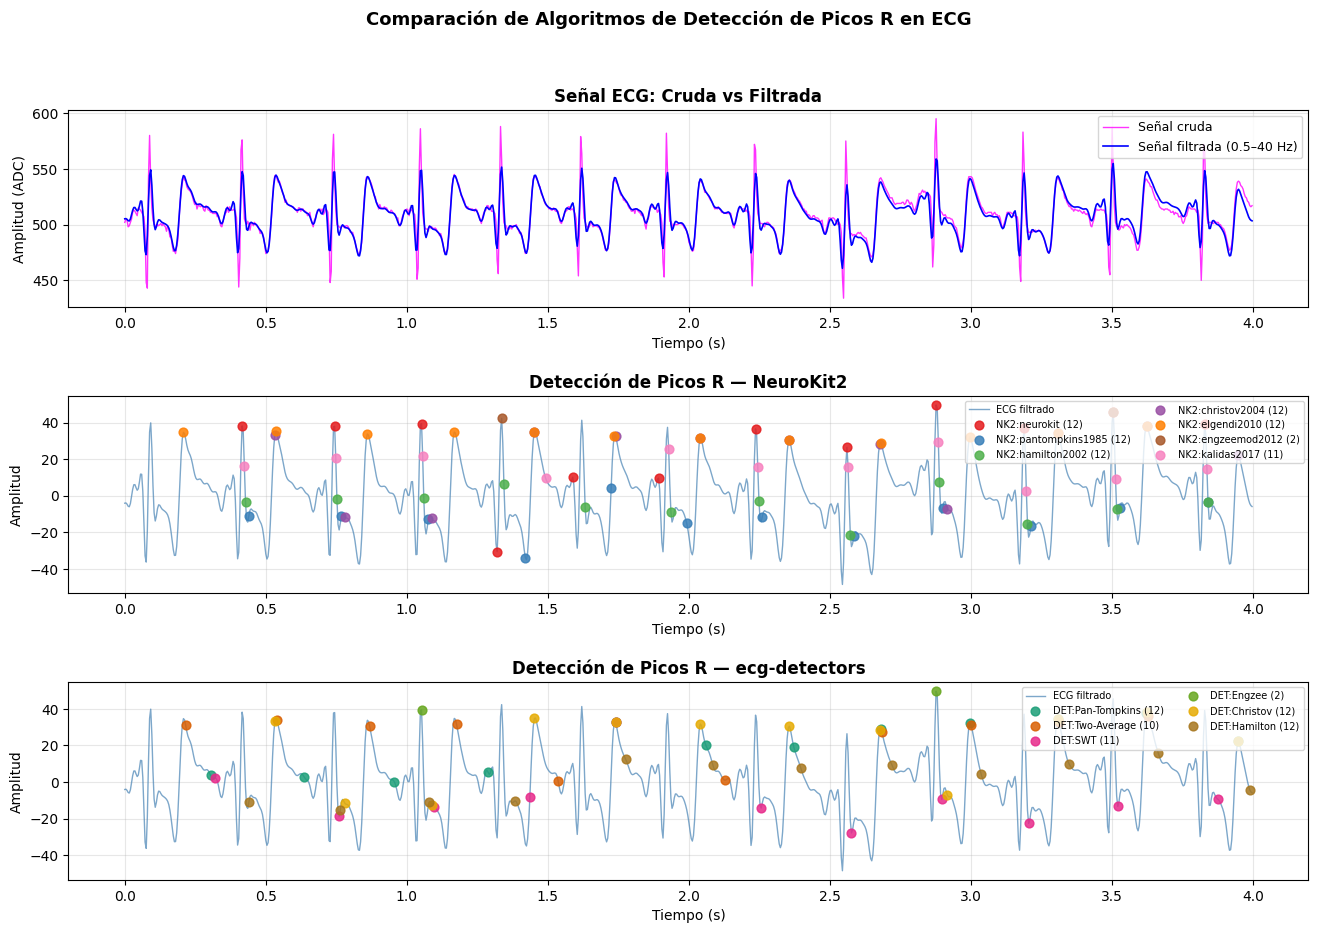


Gráfica guardada como: comparacion_picos_R.png


In [15]:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# 1. CARGA DE DATOS
CSV_PATH = "senal_ekg_tiempo.csv"  

df = pd.read_csv(CSV_PATH)
tiempo = df["Tiempo"].values
ecg_raw = df["ECG"].values.astype(float)

# Frecuencia de muestreo automática
dt = np.median(np.diff(tiempo))
if dt <= 0:
    raise ValueError("El vector de tiempo tiene valores no válidos.")
FS = round(1.0 / dt)
print(f"Frecuencia de muestreo detectada: {FS} Hz")
print(f"Duración de la señal: {tiempo[-1]:.2f} s  |  Muestras: {len(ecg_raw)}")

# 2. PRE-PROCESAMIENTO Se debe filtrar la señal?

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = fs / 2.0
    low = lowcut / nyq
    high = highcut / nyq
    # Clamp para evitar valores fuera de (0,1)
    low  = max(1e-6, min(low,  0.9999))
    high = max(1e-6, min(high, 0.9999))
    if low >= high:
        raise ValueError(f"Frecuencias de corte inválidas: low={lowcut}, high={highcut}, fs={fs}")
    b, a = butter(order, [low, high], btype="band")
    return b, a

b, a = butter_bandpass(lowcut=0.5, highcut=40.0, fs=FS, order=4)
ecg_filt = filtfilt(b, a, ecg_raw)

# Centrar la señal (eliminar offset DC)
ecg_filt = ecg_filt - np.mean(ecg_filt)

print(f"\nFiltro aplicado: paso de banda 0.5–40 Hz (Butterworth orden 4)")

# 3. DETECCIÓN CON NEUROKIT2
try:
    import neurokit2 as nk
    NK2_AVAILABLE = True
except ImportError:
    NK2_AVAILABLE = False
    print("⚠ neurokit2 no está instalado. Instala con: pip install neurokit2")

NK2_METHODS = [
    "neurokit",
    "pantompkins1985",
    "hamilton2002",
    "christov2004",
    "elgendi2010",
    "engzeemod2012",
    "kalidas2017",
]

resultados_nk2 = {}

if NK2_AVAILABLE:
    print("\n── NeuroKit2 ──────────────────────────────────────────────────────────")
    for method in NK2_METHODS:
        try:
            # np.errstate evita que operaciones internas de NK2 lancen ZeroDivisionError
            with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
                signals, info = nk.ecg_peaks(
                    ecg_filt,
                    sampling_rate=FS,
                    method=method,
                    correct_artifacts=True,   # corrección automática de artefactos
                )
            picos = info.get("ECG_R_Peaks", np.array([]))
            picos = np.array(picos, dtype=int)
            picos = picos[(picos >= 0) & (picos < len(ecg_filt))]  # bounds check

            # Calcular FC media evitando división por cero
            if len(picos) >= 2:
                rr_intervals = np.diff(picos) / FS          # en segundos
                rr_intervals = rr_intervals[rr_intervals > 0]  # evitar RR=0
                fc_media = (60.0 / rr_intervals.mean()) if rr_intervals.size > 0 else float("nan")
            else:
                fc_media = float("nan")

            resultados_nk2[method] = {"picos": picos, "fc": fc_media}
            print(f"  {method:<20} | Picos: {len(picos):>3}  | FC media: {fc_media:>6.1f} bpm")

        except ZeroDivisionError:
            print(f"  {method:<20} | ⚠ ZeroDivisionError — señal insuficiente para este método")
            resultados_nk2[method] = {"picos": np.array([]), "fc": float("nan")}
        except Exception as e:
            print(f"  {method:<20} | ⚠ Error: {e}")
            resultados_nk2[method] = {"picos": np.array([]), "fc": float("nan")}

# 4. DETECCIÓN CON ECG-DETECTORS (Detectors)

try:
    from ecgdetectors import Detectors
    DETECTORS_AVAILABLE = True
except ImportError:
    DETECTORS_AVAILABLE = False
    print("⚠ ecg-detectors no está instalado. Instala con: pip install ecg-detectors")

DET_METHODS = [
    ("Pan-Tompkins",     lambda d: d.pan_tompkins_detector(ecg_filt)),
    ("Two-Average",      lambda d: d.two_average_detector(ecg_filt)),
    ("Matched Filter",   lambda d: d.matched_filter_detector(ecg_filt, "templates/template_250hz.csv")),
    ("SWT",              lambda d: d.swt_detector(ecg_filt)),
    ("Engzee",           lambda d: d.engzee_detector(ecg_filt)),
    ("Christov",         lambda d: d.christov_detector(ecg_filt)),
    ("Hamilton",         lambda d: d.hamilton_detector(ecg_filt)),
    ("WQRS",             lambda d: d.wqrs_detector(ecg_filt)),
]

resultados_det = {}

if DETECTORS_AVAILABLE:
    print("\n── ecg-detectors (Detectors) ──────────────────────────────────────────")
    det = Detectors(FS)
    for nombre, fn in DET_METHODS:
        try:
            with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
                picos = np.array(fn(det), dtype=int)
            picos = picos[(picos >= 0) & (picos < len(ecg_filt))]

            if len(picos) >= 2:
                rr_intervals = np.diff(picos) / FS
                rr_intervals = rr_intervals[rr_intervals > 0]
                fc_media = (60.0 / rr_intervals.mean()) if rr_intervals.size > 0 else float("nan")
            else:
                fc_media = float("nan")

            resultados_det[nombre] = {"picos": picos, "fc": fc_media}
            print(f"  {nombre:<20} | Picos: {len(picos):>3}  | FC media: {fc_media:>6.1f} bpm")

        except ZeroDivisionError:
            print(f"  {nombre:<20} | ⚠ ZeroDivisionError")
            resultados_det[nombre] = {"picos": np.array([]), "fc": float("nan")}
        except Exception as e:
            print(f"  {nombre:<20} | ⚠ Error: {e}")
            resultados_det[nombre] = {"picos": np.array([]), "fc": float("nan")}

# 5. ANÁLISIS COMPARATIVO

print("\n══ COMPARACIÓN FINAL ═══════════════════════════════════════════════════")
print(f"{'Librería':<14} {'Algoritmo':<22} {'Picos':>6} {'FC (bpm)':>10} {'Válido':>7}")
print("─" * 65)

todos = []
for lib, resultados in [("NeuroKit2", resultados_nk2), ("Detectors", resultados_det)]:
    for nombre, datos in resultados.items():
        n_picos = len(datos["picos"])
        fc = datos["fc"]
        # Criterio de validez fisiológica
        valido = "✓" if (not np.isnan(fc) and 40 <= fc <= 200) else "✗"
        todos.append((lib, nombre, n_picos, fc, valido, datos["picos"]))
        print(f"{lib:<14} {nombre:<22} {n_picos:>6} {fc:>10.1f} {valido:>7}")

# Seleccionar el mejor: máx picos dentro de rango fisiológico
candidatos = [(t, n, fc, p) for lib, t, n, fc, v, p in todos if v == "✓"]
if candidatos:
    mejor = max(candidatos, key=lambda x: x[1])
    mejor_nombre = mejor[0]
    mejor_lib = next(lib for lib, t, *_ in todos if t == mejor_nombre)
    print(f"\n Mejor algoritmo: [{mejor_lib}] {mejor_nombre}")
    print(f"   Picos detectados: {mejor[1]}  |  FC media: {mejor[2]:.1f} bpm")
else:
    print("\n⚠ Ningún algoritmo produjo resultados fisiológicamente válidos.")
    print("  Verifica la señal, el filtro o la frecuencia de muestreo.")

# 6. VISUALIZACIÓN

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

# Panel 1: Señal cruda vs filtrada
ax1 = fig.add_subplot(gs[0])
ax1.plot(tiempo, ecg_raw,  color="magenta", lw=1,   label="Señal cruda", alpha=0.8)
ax1.plot(tiempo, ecg_filt + np.mean(ecg_raw), color="blue", lw=1.2, label="Señal filtrada (0.5–40 Hz)")
ax1.set_title("Señal ECG: Cruda vs Filtrada", fontsize=12, fontweight="bold")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Amplitud (ADC)")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: NeuroKit2 — mostrar los 3 mejores
ax2 = fig.add_subplot(gs[1])
ax2.plot(tiempo, ecg_filt, color="steelblue", lw=1, label="ECG filtrado", alpha=0.7)
colores_nk = plt.cm.Set1(np.linspace(0, 0.8, len(resultados_nk2)))
for i, (nombre, datos) in enumerate(resultados_nk2.items()):
    picos = datos["picos"]
    if len(picos) > 0:
        ax2.scatter(tiempo[picos], ecg_filt[picos],
                    color=colores_nk[i], s=40, zorder=5,
                    label=f"NK2:{nombre} ({len(picos)})", alpha=0.85)
ax2.set_title("Detección de Picos R — NeuroKit2", fontsize=12, fontweight="bold")
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("Amplitud")
ax2.legend(loc="upper right", fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

# Panel 3: Detectors
ax3 = fig.add_subplot(gs[2])
ax3.plot(tiempo, ecg_filt, color="steelblue", lw=1, label="ECG filtrado", alpha=0.7)
colores_det = plt.cm.Dark2(np.linspace(0, 0.9, len(resultados_det)))
for i, (nombre, datos) in enumerate(resultados_det.items()):
    picos = datos["picos"]
    if len(picos) > 0:
        ax3.scatter(tiempo[picos], ecg_filt[picos],
                    color=colores_det[i], s=40, zorder=5,
                    label=f"DET:{nombre} ({len(picos)})", alpha=0.85)
ax3.set_title("Detección de Picos R — ecg-detectors", fontsize=12, fontweight="bold")
ax3.set_xlabel("Tiempo (s)")
ax3.set_ylabel("Amplitud")
ax3.legend(loc="upper right", fontsize=7, ncol=2)
ax3.grid(True, alpha=0.3)

plt.suptitle("Comparación de Algoritmos de Detección de Picos R en ECG", fontsize=13, fontweight="bold")
plt.savefig("comparacion_picos_R.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGráfica guardada como: comparacion_picos_R.png")

Explicación de este código: 

Carga de datos - > Se lee el archivo CSV y extrae las dos columnas: el vector de tiempo y la señal ECG cruda. Luego calcula automáticamente la frecuencia de muestreo (FS = 250 Hz) dividiendo 1 entre el intervalo de tiempo entre muestras.

Filtrado de la señal --> (esto, por que se intentó hacer dectección de los picos con la señal cruda y no dio resultado) Se aplica un filtro Butterworth paso de banda 0.5–40 Hz. Esto tiene tres efectos: elimina la deriva de línea base (movimiento del cuerpo, respiración) que está por debajo de 0.5 Hz, elimina el ruido eléctrico de la red (60 Hz en Colombia) que está por encima de 40 Hz, y centra la señal en cero restando la media. La función filtfilt aplica el filtro en dos pasadas (ida y vuelta) para evitar desfase en la señal, lo cual es importante porque un pico R desplazado en el tiempo daría tiempos incorrectos..

DETECCIÓN CON NEUROKIT2
Prueba 7 algoritmos distintos de NeuroKit2 en un bucle. El bloque "with np.errstate(...)" es la solución al error que sale cuando no se puede dividir por cero (las muestras son cortas), le dice a NumPy que no lance excepciones cuando ocurre una división por cero internamente dentro de NeuroKit2, simplemente la ignora y devuelve nan en lugar de explotar. Después calcula la frecuencia cardíaca media a partir de los intervalos RR, filtrando primero los intervalos iguales a cero para evitar otra división por cero.

DETECCIÓN CON ECG-DETECTORS
Igual que la sección anterior pero con la librería Detectors, que ofrece 8 algoritmos diferentes como Pan-Tompkins, SWT, Hamilton, entre otros. Cada uno usa una estrategia matemática distinta para encontrar los picos R.

COMPARACIÓN Y SELECCIÓN DEL MEJOR
Imprime una tabla con todos los resultados y marca como válidos solo los algoritmos cuya frecuencia cardíaca detectada esté en el rango fisiológico humano (40–200 bpm). Luego elige automáticamente el que detectó más picos dentro de ese rango como el mejor. eL MEJOR





CONCLUSIÓN
*NeuroKit2
Los algoritmos más confiables son neurokit, pantompkins1985, hamilton2002, christov2004 y elgendi2010, todos con 12 picos detectados y marcados consistentemente en los picos correctos de la señal. Los problemáticos son engzeemod2012 con solo 2 picos (falló gravemente, casi no detectó nada) y kalidas2017 con 11 picos (perdió uno). Se nota además que varios puntos de distintos métodos caen en valles en lugar de picos, lo que sugiere que la señal filtrada quedó invertida en amplitud o que el offset al centrarla confundió a algunos algoritmos.
*ecg-detectors
Pan-Tompkins y Christov y Hamilton coinciden en 12 picos y se ven bien ubicados. SWT detectó 11 y Two-Average solo 10, perdiendo algunos picos al inicio. Engzee nuevamente falló con solo 2 detecciones, igual que en NeuroKit2, lo que confirma que ese algoritmo específico no es compatible con las características de tu señal.

Los mejores algoritmos para la señal EKG tomada en clase son Pan-Tompkins (disponible en ambas librerías), neurokit, hamilton2002 y christov2004, todos detectando los 12 picos correctamente y de forma consistente. Engzeemod2012 y Engzee deben descartarse completamente para esta señal.
varios puntos aparecen marcados en valles negativos en lugar de en los picos positivos. Esto puede ocurrir porque al centrar la señal con ecg_filt - mean() algunos algoritmos buscan el máximo local pero la referencia quedó desplazada. No afecta el conteo de latidos pero sí la posición exacta del pico R en el tiempo.